# 汽车是否值得购买：聚类分析 + 智能体自动寻优参数

## 任务目标

对汽车属性数据进行无监督聚类分析，比较以下三类算法：

- KMeans
- DBSCAN
- Agglomerative Clustering

并通过 LLM 自动生成参数搜索空间，在多轮搜索中寻找轮廓系数（Silhouette Score）最优的参数组合。

## 数据字段

- `buying`：购买费用
- `maint`：维修费用
- `doors`：车门数量
- `person`：乘坐人数
- `lug_boot`：行李箱容量
- `safety`：安全性（仅用于后验解释，不参与聚类训练）

## 设计原则

1. **预处理与聚类分离**
2. **训练空间与评分空间一致**
3. **LLM 只负责生成搜索空间，不负责计算真值**
4. **聚类搜索函数纯函数化**
5. **LangGraph 只负责编排，不承载核心算法逻辑**
## 1. 导入依赖

In [154]:
from __future__ import annotations

import json
import os
import re
from dataclasses import dataclass
from functools import partial
from typing import Any, Callable, Iterable, Optional, Sequence, TypedDict

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from dotenv import load_dotenv
from loguru import logger

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

from langgraph.graph import END, START, StateGraph
from langgraph.checkpoint.memory import MemorySaver

load_dotenv("./.env")

sns.set_theme(style="whitegrid")

# Choose available CJK fonts first to avoid findfont / missing glyph warnings.
preferred_cjk_fonts = [
    "Noto Sans CJK SC",
    "Noto Sans CJK TC",
    "Noto Sans CJK JP",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
]
installed_fonts = {font.name for font in fm.fontManager.ttflist}
available_fonts = [name for name in preferred_cjk_fonts if name in installed_fonts]
plt.rcParams["font.sans-serif"] = available_fonts + ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

## 2. 全局配置

In [155]:
RANDOM_STATE = 317
TARGET_SCORE = 0.53
MAX_AUTOTUNE_ROUNDS = 6
DATA_PATH = "./data/inputs/car_data.csv"

ALLOWED_LINKAGES = ("ward", "complete", "average", "single")
ALL_ALGORITHMS = ("kmeans", "dbscan", "agglomerative")

## 3. 数据结构定义

In [156]:
@dataclass(frozen=True)
class DatasetBundle:
    """Immutable preprocessed dataset bundle."""
    raw_data: pd.DataFrame
    features: pd.DataFrame
    target: pd.Series
    x: np.ndarray
    x_visual: np.ndarray
    categorical_columns: tuple[str, ...]


@dataclass(frozen=True)
class SearchResult:
    """Immutable search result for one clustering algorithm."""
    algorithm: str
    best_score: float
    best_params: dict[str, Any]
    best_labels: Optional[np.ndarray]
    history: tuple[dict[str, Any], ...]
    rounds: int
    target_score: float
    satisfied: bool

## 4. 数据预处理

注意：

- 聚类训练仅使用 5 个特征字段
- `safety` 仅用于后验解释，不参与训练
- 评分空间与训练空间统一为 `x`
- PCA 只用于可视化

In [157]:
def _build_one_hot_encoder() -> OneHotEncoder:
    """Builds a version-compatible OneHotEncoder."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def load_car_dataset(csv_path: str) -> DatasetBundle:
    """Loads and preprocesses the car dataset."""
    raw_data = pd.read_csv(csv_path)

    feature_columns = ["buying", "maint", "doors", "person", "lug_boot"]
    target_column = "safety"

    features = raw_data[feature_columns].copy()
    target = raw_data[target_column].copy()
    categorical_columns = tuple(features.columns.tolist())

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "categorical",
                _build_one_hot_encoder(),
                list(categorical_columns),
            )
        ],
        remainder="drop",
    )

    x_encoded = preprocessor.fit_transform(features)
    x_scaled = StandardScaler().fit_transform(x_encoded)
    x_visual = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(x_scaled)

    return DatasetBundle(
        raw_data=raw_data,
        features=features,
        target=target,
        x=x_scaled,
        x_visual=x_visual,
        categorical_columns=categorical_columns,
    )


dataset = load_car_dataset(DATA_PATH)
X = dataset.x
X_VISUAL = dataset.x_visual

logger.info(f"数据维度: X={X.shape}, 可视化空间={X_VISUAL.shape}")
dataset.raw_data.head()

2026-04-13 21:55:36.801 | INFO     | __main__:<module>:49 - 数据维度: X=(1728, 17), 可视化空间=(1728, 2)


,buying,maint,doors,person,lug_boot,safety
0,vhigh,2,2,small,low,unacc
1,vhigh,2,2,small,med,unacc
2,vhigh,2,2,small,high,unacc
3,vhigh,2,2,med,low,unacc
4,vhigh,2,2,med,med,unacc


In [158]:
def score_labels(x: np.ndarray, labels: np.ndarray, *, ignore_noise: bool) -> float:
    """Computes silhouette score under a consistent policy."""
    if labels is None:
        return float("-inf")

    labels_array = np.asarray(labels)

    if ignore_noise:
        mask = labels_array != -1
        if mask.sum() < 2:
            return float("-inf")
        filtered_labels = labels_array[mask]
        if len(np.unique(filtered_labels)) < 2:
            return float("-inf")
        return float(silhouette_score(x[mask], filtered_labels))

    if len(np.unique(labels_array)) < 2:
        return float("-inf")
    return float(silhouette_score(x, labels_array))

In [159]:
def float_grid(min_value: float, max_value: float, step: float) -> tuple[float, ...]:
    """Builds a closed float grid."""
    values: list[float] = []
    current = min_value
    while current <= max_value + 1e-12:
        values.append(round(current, 6))
        current += step
    return tuple(values)

## 5. 基础工具函数

In [160]:
def safe_json_loads(text: str) -> Optional[dict[str, Any]]:
    """Safely parses a JSON object from raw text."""
    if not text:
        return None

    content = text.strip()
    content = re.sub(r"^```(?:json)?\s*", "", content, flags=re.IGNORECASE)
    content = re.sub(r"\s*```$", "", content)
    match = re.search(r"\{.*\}", content, flags=re.DOTALL)
    if match:
        content = match.group(0)

    try:
        parsed = json.loads(content)
    except Exception:
        return None

    return parsed if isinstance(parsed, dict) else None


def float_grid(min_value: float, max_value: float, step: float) -> tuple[float, ...]:
    """Builds a closed float grid."""
    values: list[float] = []
    current = min_value
    while current <= max_value + 1e-12:
        values.append(round(current, 6))
        current += step
    return tuple(values)


def count_clusters(labels: Optional[np.ndarray]) -> int:
    """Counts non-noise clusters."""
    if labels is None:
        return 0
    unique_labels = set(np.asarray(labels).tolist())
    return len(unique_labels - {-1})


def noise_ratio(labels: Optional[np.ndarray]) -> float:
    """Computes noise ratio for clustering labels."""
    if labels is None:
        return 0.0
    labels_array = np.asarray(labels)
    return float(np.mean(labels_array == -1))


def cluster_distribution(labels: Optional[np.ndarray]) -> dict[int, int]:
    """Builds cluster size distribution."""
    if labels is None:
        return {}
    labels_array = np.asarray(labels)
    unique_values, counts = np.unique(labels_array, return_counts=True)
    return {int(label): int(count) for label, count in zip(unique_values, counts)}

In [161]:
def search_dbscan(
    x: np.ndarray,
    *,
    eps_min: float,
    eps_max: float,
    eps_step: float,
    min_samples_min: int,
    min_samples_max: int,
) -> dict[str, object]:
    """Searches the best DBSCAN configuration."""
    parameter_pairs = tuple(
        (eps, min_samples)
        for eps in float_grid(eps_min, eps_max, eps_step)
        for min_samples in range(min_samples_min, min_samples_max + 1)
    )

    def evaluate(pair: tuple[float, int]) -> dict[str, object]:
        eps, min_samples = pair
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(x)
        score = score_labels(x, labels, ignore_noise=True)
        return {
            "score": score,
            "params": {"eps": eps, "min_samples": min_samples},
            "labels": labels,
        }

    results = tuple(map(evaluate, parameter_pairs))
    best = max(results, key=lambda item: item["score"], default=None)

    if best is None or not np.isfinite(best["score"]):
        return {
            "best_score": float("-inf"),
            "best_params": {"eps": None, "min_samples": None, "reason": "no_valid_cluster"},
            "best_labels": None,
            "search_space": {
                "eps_min": eps_min,
                "eps_max": eps_max,
                "eps_step": eps_step,
                "min_samples_min": min_samples_min,
                "min_samples_max": min_samples_max,
            },
        }

    return {
        "best_score": float(best["score"]),
        "best_params": dict(best["params"]),
        "best_labels": best["labels"],
        "search_space": {
            "eps_min": eps_min,
            "eps_max": eps_max,
            "eps_step": eps_step,
            "min_samples_min": min_samples_min,
            "min_samples_max": min_samples_max,
        },
    }

## 6. 聚类评分函数

### 评分策略

- KMeans / Agglomerative：直接在训练空间 `X` 上计算轮廓系数
- DBSCAN：只对非噪声点 (`label != -1`) 计算轮廓系数

这样做的原因是：

1. 聚类训练与评估必须在同一几何空间进行；
2. DBSCAN 的 `-1` 是噪声标签，不应被等同于普通簇；
3. PCA 仅用于可视化，不参与调参评分，避免目标函数漂移。

In [162]:
def score_labels(
    x: np.ndarray,
    labels: Optional[np.ndarray],
    *,
    ignore_noise: bool,
) -> float:
    """Computes silhouette score under a consistent policy."""
    if labels is None:
        return float("-inf")

    labels_array = np.asarray(labels)

    if ignore_noise:
        mask = labels_array != -1
        if int(mask.sum()) < 2:
            return float("-inf")
        filtered_labels = labels_array[mask]
        if len(np.unique(filtered_labels)) < 2:
            return float("-inf")
        return float(silhouette_score(x[mask], filtered_labels))

    if len(np.unique(labels_array)) < 2:
        return float("-inf")

    return float(silhouette_score(x, labels_array))

In [163]:
def autotune(
    algorithm: str,
    generator: Callable[[tuple[dict[str, object], ...]], Optional[dict[str, object]]],
    searcher: Callable[..., dict[str, object]],
    *,
    target_score: float,
    max_rounds: int,
) -> SearchResult:
    """Runs iterative search driven by a search-space generator."""
    history: list[dict[str, object]] = []
    best_result: dict[str, object] = {
        "best_score": float("-inf"),
        "best_params": {},
        "best_labels": None,
    }

    for round_index in range(1, max_rounds + 1):
        search_space = generator(tuple(history))
        if search_space is None:
            break

        try:
            round_result = searcher(**search_space)
        except Exception as exc:  # pylint: disable=broad-exception-caught
            round_result = {
                "best_score": float("-inf"),
                "best_params": {"error": str(exc), "space": search_space},
                "best_labels": None,
                "search_space": search_space,
            }

        record = {
            "round": round_index,
            "space": search_space,
            **round_result,
        }
        history.append(record)

        if record["best_score"] > best_result["best_score"]:
            best_result = record

        if best_result["best_score"] >= target_score:
            break

    return SearchResult(
        algorithm=algorithm,
        best_score=float(best_result["best_score"]),
        best_params=dict(best_result["best_params"]),
        best_labels=best_result["best_labels"],
        history=tuple(history),
        rounds=len(history),
        satisfied=float(best_result["best_score"]) >= target_score,
        target_score=target_score,
    )

## 7. 三个纯函数搜索器

这些函数不依赖：

- LangGraph
- LLM
- Notebook 状态

它们只依赖输入数据 `x` 与搜索空间。

In [164]:
def search_kmeans(
    x: np.ndarray,
    *,
    min_clusters: int,
    max_clusters: int,
    random_state: int = RANDOM_STATE,
) -> dict[str, Any]:
    """Searches the best KMeans configuration."""
    candidates = range(min_clusters, max_clusters + 1)

    def evaluate(n_clusters: int) -> dict[str, Any]:
        model = KMeans(
            n_clusters=n_clusters,
            random_state=random_state,
            n_init=10,
        )
        labels = model.fit_predict(x)
        score = score_labels(x, labels, ignore_noise=False)
        return {
            "score": score,
            "params": {"n_clusters": n_clusters},
            "labels": labels,
        }

    results = tuple(map(evaluate, candidates))
    best = max(results, key=lambda item: item["score"], default=None)

    if best is None:
        return {
            "best_score": float("-inf"),
            "best_params": {},
            "best_labels": None,
            "search_space": {
                "min_clusters": min_clusters,
                "max_clusters": max_clusters,
            },
        }

    return {
        "best_score": float(best["score"]),
        "best_params": dict(best["params"]),
        "best_labels": best["labels"],
        "search_space": {
            "min_clusters": min_clusters,
            "max_clusters": max_clusters,
        },
    }


def search_dbscan(
    x: np.ndarray,
    *,
    eps_min: float,
    eps_max: float,
    eps_step: float,
    min_samples_min: int,
    min_samples_max: int,
) -> dict[str, Any]:
    """Searches the best DBSCAN configuration."""
    parameter_pairs = tuple(
        (eps, min_samples)
        for eps in float_grid(eps_min, eps_max, eps_step)
        for min_samples in range(min_samples_min, min_samples_max + 1)
    )

    def evaluate(pair: tuple[float, int]) -> dict[str, Any]:
        eps, min_samples = pair
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(x)
        score = score_labels(x, labels, ignore_noise=True)
        return {
            "score": score,
            "params": {"eps": eps, "min_samples": min_samples},
            "labels": labels,
        }

    results = tuple(map(evaluate, parameter_pairs))
    best = max(results, key=lambda item: item["score"], default=None)

    if best is None or not np.isfinite(best["score"]):
        return {
            "best_score": float("-inf"),
            "best_params": {
                "eps": None,
                "min_samples": None,
                "reason": "no_valid_cluster",
            },
            "best_labels": None,
            "search_space": {
                "eps_min": eps_min,
                "eps_max": eps_max,
                "eps_step": eps_step,
                "min_samples_min": min_samples_min,
                "min_samples_max": min_samples_max,
            },
        }

    return {
        "best_score": float(best["score"]),
        "best_params": dict(best["params"]),
        "best_labels": best["labels"],
        "search_space": {
            "eps_min": eps_min,
            "eps_max": eps_max,
            "eps_step": eps_step,
            "min_samples_min": min_samples_min,
            "min_samples_max": min_samples_max,
        },
    }


def search_agglomerative(
    x: np.ndarray,
    *,
    linkages: Sequence[str],
    min_clusters: int,
    max_clusters: int,
) -> dict[str, Any]:
    """Searches the best AgglomerativeClustering configuration."""
    parameter_pairs = tuple(
        (linkage, n_clusters)
        for linkage in linkages
        for n_clusters in range(min_clusters, max_clusters + 1)
    )

    def evaluate(pair: tuple[str, int]) -> dict[str, Any]:
        linkage, n_clusters = pair
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage=linkage,
        )
        labels = model.fit_predict(x)
        score = score_labels(x, labels, ignore_noise=False)
        return {
            "score": score,
            "params": {"linkage": linkage, "n_clusters": n_clusters},
            "labels": labels,
        }

    results = tuple(map(evaluate, parameter_pairs))
    best = max(results, key=lambda item: item["score"], default=None)

    if best is None:
        return {
            "best_score": float("-inf"),
            "best_params": {},
            "best_labels": None,
            "search_space": {
                "linkages": tuple(linkages),
                "min_clusters": min_clusters,
                "max_clusters": max_clusters,
            },
        }

    return {
        "best_score": float(best["score"]),
        "best_params": dict(best["params"]),
        "best_labels": best["labels"],
        "search_space": {
            "linkages": tuple(linkages),
            "min_clusters": min_clusters,
            "max_clusters": max_clusters,
        },
    }

## 8. LLM 客户端与安全包装

设计原则：

- LLM 不做真值判断，只提议“下一轮搜索空间”
- 若 LLM 不可用，则回退到确定性默认搜索空间

In [165]:
class Agent:
    """Singleton-like lightweight LLM holder."""
    _instance: Optional["Agent"] = None

    def __new__(cls) -> "Agent":
        if cls._instance is None:
            cls._instance = super().__new__(cls)
        return cls._instance  # type: ignore[return-value]

    def __init__(self) -> None:
        if getattr(self, "_initialized", False):
            return

        api_key = os.getenv("OPENAI_API_KEY", "").strip()
        if not api_key:
            self.llm = None
            self._initialized = True
            return

        self.llm = ChatOpenAI(
            model=os.getenv("OPENAI_MODEL", "gpt-4o-mini"),
            api_key=api_key,
            base_url=os.getenv("OPENAI_BASE_URL", "https://api.openai.com/v1"),
            temperature=0.2,
            streaming=False,
        )
        self._initialized = True


agent = Agent()

In [166]:
def llm_available() -> bool:
    """Checks whether an LLM client is available."""
    return getattr(agent, "llm", None) is not None


def llm_invoke(messages: list[BaseMessage]) -> AIMessage:
    """Invokes the LLM and returns an AIMessage.

    Some model deployments require streaming mode (for example when
    enable_thinking is on). This function transparently falls back
    to stream aggregation when non-streaming invoke is rejected.
    """
    if not llm_available():
        raise RuntimeError("LLM is not available. Please configure OPENAI_API_KEY.")

    try:
        response = agent.llm.invoke(messages)
        if isinstance(response, AIMessage):
            return response
        return AIMessage(content=getattr(response, "content", str(response)))
    except Exception as exc:
        error_text = str(exc)
        requires_stream = "enable_thinking" in error_text or "non-streaming" in error_text
        if not requires_stream:
            raise

    streamed_chunks = list(agent.llm.stream(messages))
    if not streamed_chunks:
        return AIMessage(content="")

    merged = streamed_chunks[0]
    for chunk in streamed_chunks[1:]:
        merged = merged + chunk

    if isinstance(merged, AIMessage):
        return merged
    return AIMessage(content=getattr(merged, "content", str(merged)))

## 9. 搜索空间生成器

这里采用：

- **优先使用 LLM 生成下一轮参数空间**
- **若解析失败，则回退到默认空间**
- 所有边界都进行强约束

In [167]:
def default_space_kmeans(history: Sequence[dict[str, Any]]) -> dict[str, Any]:
    """Fallback search space for KMeans."""
    if not history:
        return {"min_clusters": 2, "max_clusters": 10}
    return {"min_clusters": 2, "max_clusters": 15}


def default_space_dbscan(history: Sequence[dict[str, Any]]) -> dict[str, Any]:
    """Fallback search space for DBSCAN."""
    if not history:
        return {
            "eps_min": 0.10,
            "eps_max": 1.20,
            "eps_step": 0.05,
            "min_samples_min": 3,
            "min_samples_max": 12,
        }
    return {
        "eps_min": 0.05,
        "eps_max": 1.50,
        "eps_step": 0.05,
        "min_samples_min": 2,
        "min_samples_max": 15,
    }


def default_space_agglomerative(history: Sequence[dict[str, Any]]) -> dict[str, Any]:
    """Fallback search space for AgglomerativeClustering."""
    if not history:
        return {
            "linkages": ["ward", "complete", "average"],
            "min_clusters": 2,
            "max_clusters": 10,
        }
    return {
        "linkages": list(ALLOWED_LINKAGES),
        "min_clusters": 2,
        "max_clusters": 15,
    }

In [168]:
def generate_space_kmeans(history: Sequence[dict[str, Any]]) -> dict[str, Any]:
    """Generates the next KMeans search space."""
    fallback = default_space_kmeans(history)
    if not llm_available():
        return fallback

    system_prompt = SystemMessage(
        content=(
            "你是 KMeans 聚类参数搜索空间生成器。"
            "只输出 JSON，不要输出额外解释。"
            "输出格式："
            "{\"min_clusters\": 整数, \"max_clusters\": 整数, \"reason\": \"简短原因\"}。"
            "限制：min_clusters ∈ [2, 15]，max_clusters ∈ [min_clusters, 15]。"
        )
    )
    human_prompt = HumanMessage(
        content=(
            f"目标轮廓系数: {TARGET_SCORE}\n"
            f"历史记录: {json.dumps(list(history), ensure_ascii=False, default=str)}\n"
            "请生成下一轮最有潜力的搜索范围。"
        )
    )

    try:
        response = llm_invoke([system_prompt, human_prompt])
        parsed = safe_json_loads(response.content) or {}
    except Exception:
        return fallback

    min_clusters = parsed.get("min_clusters", fallback["min_clusters"])
    max_clusters = parsed.get("max_clusters", fallback["max_clusters"])

    try:
        min_clusters = int(min_clusters)
        max_clusters = int(max_clusters)
    except Exception:
        return fallback

    min_clusters = max(2, min(min_clusters, 15))
    max_clusters = max(min_clusters, min(max_clusters, 15))

    return {
        "min_clusters": min_clusters,
        "max_clusters": max_clusters,
    }


def generate_space_dbscan(history: Sequence[dict[str, Any]]) -> dict[str, Any]:
    """Generates the next DBSCAN search space."""
    fallback = default_space_dbscan(history)
    if not llm_available():
        return fallback

    system_prompt = SystemMessage(
        content=(
            "你是 DBSCAN 聚类参数搜索空间生成器。"
            "只输出 JSON，不要输出额外解释。"
            "输出格式："
            "{\"eps_min\": 浮点数, \"eps_max\": 浮点数, \"eps_step\": 浮点数, "
            "\"min_samples_min\": 整数, \"min_samples_max\": 整数, \"reason\": \"简短原因\"}。"
            "限制：eps ∈ [0.01, 2.0]，eps_min < eps_max，eps_step ∈ [0.01, 0.5]，"
            "min_samples ∈ [2, 20]，min_samples_min < min_samples_max。"
        )
    )
    human_prompt = HumanMessage(
        content=(
            f"目标轮廓系数: {TARGET_SCORE}\n"
            f"历史记录: {json.dumps(list(history), ensure_ascii=False, default=str)}\n"
            "请生成下一轮最有潜力的搜索范围。"
        )
    )

    try:
        response = llm_invoke([system_prompt, human_prompt])
        parsed = safe_json_loads(response.content) or {}
    except Exception:
        return fallback

    try:
        eps_min = float(parsed.get("eps_min", fallback["eps_min"]))
        eps_max = float(parsed.get("eps_max", fallback["eps_max"]))
        eps_step = float(parsed.get("eps_step", fallback["eps_step"]))
        min_samples_min = int(parsed.get("min_samples_min", fallback["min_samples_min"]))
        min_samples_max = int(parsed.get("min_samples_max", fallback["min_samples_max"]))
    except Exception:
        return fallback

    eps_min = max(0.01, min(eps_min, 2.0))
    eps_max = max(eps_min + 0.01, min(eps_max, 2.0))
    eps_step = max(0.01, min(eps_step, 0.5))
    min_samples_min = max(2, min(min_samples_min, 20))
    min_samples_max = max(min_samples_min + 1, min(min_samples_max, 20))

    return {
        "eps_min": eps_min,
        "eps_max": eps_max,
        "eps_step": eps_step,
        "min_samples_min": min_samples_min,
        "min_samples_max": min_samples_max,
    }


def generate_space_agglomerative(history: Sequence[dict[str, Any]]) -> dict[str, Any]:
    """Generates the next AgglomerativeClustering search space."""
    fallback = default_space_agglomerative(history)
    if not llm_available():
        return fallback

    system_prompt = SystemMessage(
        content=(
            "你是分层聚类参数搜索空间生成器。"
            "只输出 JSON，不要输出额外解释。"
            "输出格式："
            "{\"linkages\": [\"ward\", \"complete\", \"average\", \"single\"], "
            "\"min_clusters\": 整数, \"max_clusters\": 整数, \"reason\": \"简短原因\"}。"
            "限制：min_clusters ∈ [2, 15]，max_clusters ∈ [min_clusters, 15]，"
            "linkages 只能从 [ward, complete, average, single] 中选择。"
        )
    )
    human_prompt = HumanMessage(
        content=(
            f"目标轮廓系数: {TARGET_SCORE}\n"
            f"历史记录: {json.dumps(list(history), ensure_ascii=False, default=str)}\n"
            "请生成下一轮最有潜力的搜索范围。"
        )
    )

    try:
        response = llm_invoke([system_prompt, human_prompt])
        parsed = safe_json_loads(response.content) or {}
    except Exception:
        return fallback

    raw_linkages = parsed.get("linkages", fallback["linkages"])
    if isinstance(raw_linkages, str):
        linkages = [raw_linkages]
    elif isinstance(raw_linkages, list):
        linkages = [item for item in raw_linkages if item in ALLOWED_LINKAGES]
    else:
        linkages = list(fallback["linkages"])

    if not linkages:
        linkages = list(fallback["linkages"])

    try:
        min_clusters = int(parsed.get("min_clusters", fallback["min_clusters"]))
        max_clusters = int(parsed.get("max_clusters", fallback["max_clusters"]))
    except Exception:
        return fallback

    min_clusters = max(2, min(min_clusters, 15))
    max_clusters = max(min_clusters, min(max_clusters, 15))

    return {
        "linkages": linkages,
        "min_clusters": min_clusters,
        "max_clusters": max_clusters,
    }

## 10. 自动调参控制器

高阶函数形式：

- `generator(history) -> search_space`
- `searcher(**search_space) -> round_result`

这样可以把“提议空间”和“执行搜索”完全解耦。

In [169]:
def autotune(
    algorithm: str,
    generator: Callable[[Sequence[dict[str, Any]]], dict[str, Any]],
    searcher: Callable[..., dict[str, Any]],
    *,
    target_score: float = TARGET_SCORE,
    max_rounds: int = MAX_AUTOTUNE_ROUNDS,
) -> SearchResult:
    """Runs iterative search with an external search-space generator."""
    history: list[dict[str, Any]] = []
    best_result: dict[str, Any] = {
        "best_score": float("-inf"),
        "best_params": {},
        "best_labels": None,
    }

    for round_index in range(1, max_rounds + 1):
        search_space = generator(tuple(history))

        try:
            round_result = searcher(**search_space)
        except Exception as exc:
            round_result = {
                "best_score": float("-inf"),
                "best_params": {
                    "error": str(exc),
                    "search_space": search_space,
                },
                "best_labels": None,
                "search_space": search_space,
            }

        record = {
            "round": round_index,
            "space": search_space,
            **round_result,
        }
        history.append(record)

        if record["best_score"] > best_result["best_score"]:
            best_result = record

        if float(best_result["best_score"]) >= target_score:
            break

    return SearchResult(
        algorithm=algorithm,
        best_score=float(best_result["best_score"]),
        best_params=dict(best_result["best_params"]),
        best_labels=best_result["best_labels"],
        history=tuple(history),
        rounds=len(history),
        target_score=target_score,
        satisfied=float(best_result["best_score"]) >= target_score,
    )

## 11. 聚类解释与报告构建

`safety` 不参与训练，但可以用于解释：

- 每个簇中 `safety` 的分布
- 聚类结构是否与安全性分层具有对应关系

In [170]:
def build_target_cluster_table(
    labels: Optional[np.ndarray],
    target: pd.Series,
) -> pd.DataFrame:
    """Builds a crosstab of cluster labels and target labels."""
    if labels is None:
        return pd.DataFrame()

    frame = pd.DataFrame(
        {
            "cluster": np.asarray(labels),
            "target": target.reset_index(drop=True),
        }
    )
    table = pd.crosstab(frame["cluster"], frame["target"], normalize="index")
    return table.round(4)


def clustering_health_metrics(labels: Optional[np.ndarray]) -> dict[str, float]:
    """Computes practical clustering health metrics."""
    if labels is None:
        return {
            "cluster_count": 0.0,
            "noise_ratio": 0.0,
            "largest_cluster_ratio": 0.0,
            "singleton_ratio": 0.0,
        }

    labels_array = np.asarray(labels).astype(int)
    valid_labels = labels_array[labels_array != -1]

    if valid_labels.size == 0:
        return {
            "cluster_count": 0.0,
            "noise_ratio": float(np.mean(labels_array == -1)),
            "largest_cluster_ratio": 0.0,
            "singleton_ratio": 0.0,
        }

    _, counts = np.unique(valid_labels, return_counts=True)
    cluster_count = float(len(counts))
    largest_cluster_ratio = float(counts.max() / max(1, valid_labels.size))
    singleton_ratio = float(np.mean(counts == 1))

    return {
        "cluster_count": cluster_count,
        "noise_ratio": float(np.mean(labels_array == -1)),
        "largest_cluster_ratio": largest_cluster_ratio,
        "singleton_ratio": singleton_ratio,
    }


def practical_score(
    raw_score: float,
    labels: Optional[np.ndarray],
) -> tuple[float, dict[str, float]]:
    """Penalizes impractical clustering structures while preserving silhouette quality."""
    if not np.isfinite(raw_score):
        return float("-inf"), {
            "cluster_penalty": 1.0,
            "noise_penalty": 1.0,
            "imbalance_penalty": 1.0,
            "singleton_penalty": 1.0,
        }

    metrics = clustering_health_metrics(labels)
    cluster_count = metrics["cluster_count"]
    noise = metrics["noise_ratio"]
    largest_ratio = metrics["largest_cluster_ratio"]
    singleton_ratio = metrics["singleton_ratio"]

    if cluster_count < 2:
        cluster_penalty = 0.8
    elif cluster_count <= 12:
        cluster_penalty = 0.0
    elif cluster_count <= 20:
        cluster_penalty = 0.03 * (cluster_count - 12)
    else:
        cluster_penalty = min(0.24 + 0.008 * (cluster_count - 20), 0.9)

    noise_penalty = max(0.0, noise - 0.35) * 0.6
    imbalance_penalty = max(0.0, largest_ratio - 0.75) * 0.5
    singleton_penalty = max(0.0, singleton_ratio - 0.25) * 0.5

    score = raw_score - cluster_penalty - noise_penalty - imbalance_penalty - singleton_penalty
    penalty_detail = {
        "cluster_penalty": float(cluster_penalty),
        "noise_penalty": float(noise_penalty),
        "imbalance_penalty": float(imbalance_penalty),
        "singleton_penalty": float(singleton_penalty),
    }
    return float(score), penalty_detail


def build_comparison_table(
    result_map: dict[str, SearchResult],
) -> pd.DataFrame:
    """Builds a comparison table across algorithms with practical scoring."""
    rows: list[dict[str, Any]] = []
    for result in result_map.values():
        metrics = clustering_health_metrics(result.best_labels)
        adjusted_score, penalty_detail = practical_score(result.best_score, result.best_labels)
        rows.append(
            {
                "algorithm": result.algorithm,
                "score": result.best_score,
                "practical_score": adjusted_score,
                "clusters": int(metrics["cluster_count"]),
                "noise_ratio": metrics["noise_ratio"],
                "largest_cluster_ratio": metrics["largest_cluster_ratio"],
                "singleton_ratio": metrics["singleton_ratio"],
                "penalty_detail": penalty_detail,
                "params": result.best_params,
                "rounds": result.rounds,
                "satisfied": result.satisfied,
            }
        )

    if not rows:
        return pd.DataFrame()

    return pd.DataFrame(rows).sort_values("practical_score", ascending=False).reset_index(drop=True)


def build_cluster_report(
    result_map: dict[str, SearchResult],
    target: pd.Series,
    *,
    preferred_algorithm: Optional[str] = None,
    preferred_reason: str = "",
) -> dict[str, Any]:
    """Builds a structured cluster report."""
    if not result_map:
        return {
            "best_algorithm": "N/A",
            "best_score": float("-inf"),
            "best_practical_score": float("-inf"),
            "best_params": {},
            "comparison_table": pd.DataFrame(),
            "target_cluster_table": pd.DataFrame(),
            "report_text": "没有可用的聚类结果。",
        }

    comparison_table = build_comparison_table(result_map)

    if preferred_algorithm and preferred_algorithm in result_map:
        best = result_map[preferred_algorithm]
    else:
        best_algorithm = str(comparison_table.iloc[0]["algorithm"] if not comparison_table.empty else "")
        best = result_map.get(best_algorithm, max(result_map.values(), key=lambda item: item.best_score))

    best_metrics = clustering_health_metrics(best.best_labels)
    best_practical_score, _ = practical_score(best.best_score, best.best_labels)
    target_cluster_table = build_target_cluster_table(best.best_labels, target)

    report_lines = [
        f"最佳算法: {best.algorithm}",
        f"原始轮廓系数: {best.best_score:.4f}",
        f"实用性评分: {best_practical_score:.4f}",
        f"最佳参数: {best.best_params}",
        f"簇数量: {int(best_metrics['cluster_count'])}",
        f"噪声比例: {best_metrics['noise_ratio']:.2%}",
        f"最大簇占比: {best_metrics['largest_cluster_ratio']:.2%}",
        f"单点簇占比: {best_metrics['singleton_ratio']:.2%}",
    ]

    if preferred_reason:
        report_lines.extend(["", f"LLM 决策理由: {preferred_reason}"])

    report_lines.extend(["", "算法对比（按实用性评分排序）:"])
    for _, row in comparison_table.iterrows():
        report_lines.append(
            f"- {row['algorithm']}: "
            f"practical={row['practical_score']:.4f}, "
            f"raw={row['score']:.4f}, "
            f"clusters={int(row['clusters'])}, "
            f"noise={row['noise_ratio']:.2%}, "
            f"largest={row['largest_cluster_ratio']:.2%}, "
            f"singleton={row['singleton_ratio']:.2%}, "
            f"params={row['params']}"
        )

    if not target_cluster_table.empty:
        report_lines.extend(
            [
                "",
                "最佳算法簇内 safety 分布（按行归一化）:",
                target_cluster_table.to_string(),
            ]
        )

    return {
        "best_algorithm": best.algorithm,
        "best_score": best.best_score,
        "best_practical_score": best_practical_score,
        "best_params": best.best_params,
        "best_labels": best.best_labels,
        "comparison_table": comparison_table,
        "target_cluster_table": target_cluster_table,
        "report_text": "\n".join(report_lines),
    }

## 12. 可视化函数

In [171]:
def plot_best_clusters(
    x_visual: np.ndarray,
    labels: Optional[np.ndarray],
    *,
    title: str,
) -> None:
    """Plots 2D PCA visualization for cluster labels."""
    if labels is None:
        print(f"{title}: 无可视化标签")
        return

    frame = pd.DataFrame(
        {
            "pc1": x_visual[:, 0],
            "pc2": x_visual[:, 1],
            "cluster": np.asarray(labels).astype(int),
        }
    )

    cluster_count = int(frame["cluster"].nunique())
    show_legend = cluster_count <= 20

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=frame,
        x="pc1",
        y="pc2",
        hue="cluster",
        palette="tab10",
        s=36,
        alpha=0.85,
        legend="brief" if show_legend else False,
    )

    final_title = title if show_legend else f"{title}（簇数={cluster_count}，图例已隐藏）"
    plt.title(final_title)
    plt.tight_layout()
    plt.show()


def plot_comparison_table(comparison_table: pd.DataFrame) -> None:
    """Plots algorithm score comparison."""
    if comparison_table.empty:
        print("暂无可视化结果")
        return

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=comparison_table,
        x="algorithm",
        y="score",
        palette="Set2",
    )
    plt.title("聚类算法轮廓系数对比")
    plt.ylabel("Silhouette Score")
    plt.xlabel("Algorithm")
    plt.tight_layout()
    plt.show()

## 13. Tool 封装

Tool 层只做轻量包装，真正的逻辑仍在纯函数中。

In [172]:
@tool
def kmeans_analysis() -> dict[str, Any]:
    """Runs iterative KMeans search."""
    result = autotune(
        "KMeans",
        generator=generate_space_kmeans,
        searcher=partial(search_kmeans, X),
    )
    return {
        "algorithm": result.algorithm,
        "best_score": result.best_score,
        "best_params": result.best_params,
        "best_labels": result.best_labels.tolist() if result.best_labels is not None else None,
        "history": list(result.history),
        "rounds": result.rounds,
        "target_score": result.target_score,
        "satisfied": result.satisfied,
    }


@tool
def dbscan_analysis() -> dict[str, Any]:
    """Runs iterative DBSCAN search."""
    result = autotune(
        "DBSCAN",
        generator=generate_space_dbscan,
        searcher=partial(search_dbscan, X),
    )
    return {
        "algorithm": result.algorithm,
        "best_score": result.best_score,
        "best_params": result.best_params,
        "best_labels": result.best_labels.tolist() if result.best_labels is not None else None,
        "history": list(result.history),
        "rounds": result.rounds,
        "target_score": result.target_score,
        "satisfied": result.satisfied,
    }


@tool
def agglomerative_analysis() -> dict[str, Any]:
    """Runs iterative AgglomerativeClustering search."""
    result = autotune(
        "Agglomerative",
        generator=generate_space_agglomerative,
        searcher=partial(search_agglomerative, X),
    )
    return {
        "algorithm": result.algorithm,
        "best_score": result.best_score,
        "best_params": result.best_params,
        "best_labels": result.best_labels.tolist() if result.best_labels is not None else None,
        "history": list(result.history),
        "rounds": result.rounds,
        "target_score": result.target_score,
        "satisfied": result.satisfied,
    }

## 14. Agent 状态定义

In [173]:
class AgentState(TypedDict):
    """State for LangGraph orchestration."""
    query: str
    messages: list[BaseMessage]
    selected_algorithms: list[str]
    kmeans_result: Optional[dict[str, Any]]
    dbscan_result: Optional[dict[str, Any]]
    agglomerative_result: Optional[dict[str, Any]]
    final_output: Optional[str]
    best_algorithm_name: Optional[str]
    best_algorithm_score: Optional[float]
    best_algorithm_params: Optional[dict[str, Any]]
    llm_planner_reason: Optional[str]
    llm_judge_reason: Optional[str]
    comparison_table: Optional[list[dict[str, Any]]]
    target_cluster_table: Optional[list[dict[str, Any]]]
    results_log: list[str]

## 15. 路由策略

原方案里的 embedding 工具选择器被移除。

原因很简单：这里工具集非常小，规则路由比语义向量检索更稳定、更可解释、更低成本。

In [174]:
def select_algorithms_from_query(query: str) -> list[str]:
    """Selects algorithms from user query via deterministic routing."""
    normalized = query.lower()

    if re.search(r"比较|对比|不同算法|最佳|哪个|效果", query):
        return list(ALL_ALGORITHMS)

    selected: list[str] = []
    if "kmeans" in normalized or "k-means" in normalized:
        selected.append("kmeans")
    if "dbscan" in normalized:
        selected.append("dbscan")
    if re.search(r"层次|分层|凝聚|agglomerative", query, flags=re.IGNORECASE):
        selected.append("agglomerative")

    return selected or list(ALL_ALGORITHMS)

## 16. LangGraph 节点函数

In [175]:
def planner_with_llm(query: str) -> tuple[list[str], str]:
    """Uses LLM to choose which algorithms should run, with deterministic fallback."""
    fallback = select_algorithms_from_query(query)
    if not llm_available():
        return fallback, "LLM 不可用，使用规则路由。"

    system_prompt = SystemMessage(
        content=(
            "你是聚类实验规划器。请根据用户意图输出 JSON，不要输出多余内容。"
            "格式: {\"selected_algorithms\": [\"kmeans\"|\"dbscan\"|\"agglomerative\"], \"reason\": \"简短原因\"}。"
            "要求: 至少选择 1 个算法，最多 3 个；若用户强调可解释/可落地，可减少候选数量。"
        )
    )
    human_prompt = HumanMessage(content=f"用户请求: {query}")

    try:
        response = llm_invoke([system_prompt, human_prompt])
        parsed = safe_json_loads(response.content) or {}
    except Exception as exc:
        return fallback, f"LLM 规划失败，回退规则路由: {exc}"

    raw_algs = parsed.get("selected_algorithms", [])
    if isinstance(raw_algs, str):
        raw_algs = [raw_algs]

    selected = [item for item in raw_algs if item in ALL_ALGORITHMS]
    if not selected:
        selected = fallback

    reason = str(parsed.get("reason", "")) or "LLM 已参与算法选择。"
    return selected, reason


def judge_best_algorithm_with_llm(comparison_rows: list[dict[str, Any]]) -> tuple[Optional[str], str]:
    """Uses LLM to pick the best algorithm from computed metrics."""
    if not comparison_rows:
        return None, "没有候选结果。"
    if not llm_available():
        return None, "LLM 不可用，使用规则评分排序。"

    compact_rows = [
        {
            "algorithm": row.get("algorithm"),
            "practical_score": row.get("practical_score"),
            "score": row.get("score"),
            "clusters": row.get("clusters"),
            "noise_ratio": row.get("noise_ratio"),
            "largest_cluster_ratio": row.get("largest_cluster_ratio"),
            "singleton_ratio": row.get("singleton_ratio"),
            "params": row.get("params"),
        }
        for row in comparison_rows
    ]

    system_prompt = SystemMessage(
        content=(
            "你是聚类结果裁决器。目标是选出可落地、可解释、质量高的结果，而不是盲目最大化轮廓系数。"
            "请输出 JSON: {\"best_algorithm\": \"KMeans|DBSCAN|Agglomerative\", \"reason\": \"简短理由\"}。"
            "如果出现簇数量过多(例如>30)或大量单点簇，应强烈降权。"
        )
    )
    human_prompt = HumanMessage(
        content=f"候选结果: {json.dumps(compact_rows, ensure_ascii=False, default=str)}"
    )

    try:
        response = llm_invoke([system_prompt, human_prompt])
        parsed = safe_json_loads(response.content) or {}
    except Exception as exc:
        return None, f"LLM 裁决失败，回退规则评分: {exc}"

    best_algorithm = parsed.get("best_algorithm")
    if best_algorithm not in {"KMeans", "DBSCAN", "Agglomerative"}:
        return None, "LLM 输出算法名无效，回退规则评分。"

    reason = str(parsed.get("reason", "")) or "LLM 已参与最终裁决。"
    return str(best_algorithm), reason


def planner_node(state: AgentState) -> dict[str, Any]:
    """Determines which clustering algorithms should run."""
    selected_algorithms, reason = planner_with_llm(state["query"])
    log_line = f"已选择算法: {selected_algorithms} | 规划理由: {reason}"
    logger.info(log_line)
    return {
        "selected_algorithms": selected_algorithms,
        "llm_planner_reason": reason,
        "results_log": state["results_log"] + [log_line],
    }


def _tool_result_to_search_result(raw_result: dict[str, Any]) -> SearchResult:
    """Converts tool return dict to immutable SearchResult."""
    labels = raw_result.get("best_labels")
    labels_array = None if labels is None else np.asarray(labels)

    return SearchResult(
        algorithm=str(raw_result.get("algorithm", "Unknown")),
        best_score=float(raw_result.get("best_score", float("-inf"))),
        best_params=dict(raw_result.get("best_params", {})),
        best_labels=labels_array,
        history=tuple(raw_result.get("history", [])),
        rounds=int(raw_result.get("rounds", 0)),
        target_score=float(raw_result.get("target_score", TARGET_SCORE)),
        satisfied=bool(raw_result.get("satisfied", False)),
    )


def execute_selected_algorithms_node(state: AgentState) -> dict[str, Any]:
    """Executes only algorithms chosen by planner (LLM-driven)."""
    selected = state.get("selected_algorithms", [])
    result_updates: dict[str, Any] = {
        "kmeans_result": None,
        "dbscan_result": None,
        "agglomerative_result": None,
    }
    logs = list(state["results_log"])

    algorithm_runners: dict[str, tuple[str, Callable[[], dict[str, Any]], str]] = {
        "kmeans": ("KMeans", lambda: kmeans_analysis.invoke({}), "kmeans_result"),
        "dbscan": ("DBSCAN", lambda: dbscan_analysis.invoke({}), "dbscan_result"),
        "agglomerative": ("Agglomerative", lambda: agglomerative_analysis.invoke({}), "agglomerative_result"),
    }

    for algorithm_key in selected:
        if algorithm_key not in algorithm_runners:
            continue
        algorithm_name, run_func, state_key = algorithm_runners[algorithm_key]
        logger.info(f"开始执行 {algorithm_name} 自动调参...")
        result = run_func()
        result_updates[state_key] = result
        log_line = (
            f"{algorithm_name} 完成: score={result['best_score']:.4f}, "
            f"params={result['best_params']}, rounds={result['rounds']}"
        )
        logger.info(log_line)
        logs.append(log_line)

    return {**result_updates, "results_log": logs}


def aggregate_node(state: AgentState) -> dict[str, Any]:
    """Aggregates all algorithm results and builds the final report."""
    result_map: dict[str, SearchResult] = {}

    if state.get("kmeans_result"):
        result_map["KMeans"] = _tool_result_to_search_result(state["kmeans_result"])
    if state.get("dbscan_result"):
        result_map["DBSCAN"] = _tool_result_to_search_result(state["dbscan_result"])
    if state.get("agglomerative_result"):
        result_map["Agglomerative"] = _tool_result_to_search_result(
            state["agglomerative_result"]
        )

    comparison_table = build_comparison_table(result_map)
    comparison_rows = comparison_table.to_dict(orient="records")
    llm_best_algorithm, judge_reason = judge_best_algorithm_with_llm(comparison_rows)

    report = build_cluster_report(
        result_map,
        dataset.target,
        preferred_algorithm=llm_best_algorithm,
        preferred_reason=judge_reason,
    )

    return {
        "final_output": report["report_text"],
        "best_algorithm_name": report["best_algorithm"],
        "best_algorithm_score": report["best_score"],
        "best_algorithm_params": report["best_params"],
        "llm_judge_reason": judge_reason,
        "comparison_table": report["comparison_table"].to_dict(orient="records"),
        "target_cluster_table": report["target_cluster_table"].reset_index().to_dict(orient="records")
        if not report["target_cluster_table"].empty
        else [],
        "results_log": state["results_log"] + [f"已生成最终报告 | 裁决理由: {judge_reason}"],
    }


def reply_node(state: AgentState) -> dict[str, Any]:
    """Builds the final assistant message."""
    final_output = state.get("final_output") or "无结果"
    return {
        "messages": state["messages"] + [AIMessage(content=final_output)],
        "final_output": final_output,
    }

## 17. 构建并编译 LangGraph

In [176]:
builder = StateGraph(AgentState)

builder.add_node("planner", planner_node)
builder.add_node("execute_selected", execute_selected_algorithms_node)
builder.add_node("aggregate", aggregate_node)
builder.add_node("reply", reply_node)

builder.add_edge(START, "planner")
builder.add_edge("planner", "execute_selected")
builder.add_edge("execute_selected", "aggregate")
builder.add_edge("aggregate", "reply")
builder.add_edge("reply", END)

graph = builder.compile(checkpointer=MemorySaver())

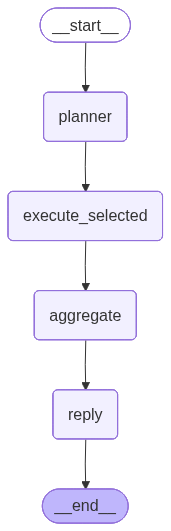

In [ ]:
# from IPython.display import Image, display
# display(Image(graph.get_graph().draw_mermaid_png()))

In [178]:
query = "帮我做聚类分析，比较不同算法效果"

initial_state: AgentState = {
    "query": query,
    "messages": [HumanMessage(content=query)],
    "selected_algorithms": [],
    "kmeans_result": None,
    "dbscan_result": None,
    "agglomerative_result": None,
    "final_output": None,
    "best_algorithm_name": None,
    "best_algorithm_score": None,
    "best_algorithm_params": None,
    "llm_planner_reason": None,
    "llm_judge_reason": None,
    "comparison_table": None,
    "target_cluster_table": None,
    "results_log": [],
}

config = {
    "configurable": {
        "thread_id": "car-clustering-autotune-001",
    }
}

final_state = graph.invoke(initial_state, config=config)
print(final_state["final_output"])

2026-04-13 21:55:44.753 | INFO     | __main__:planner_node:84 - 已选择算法: ['kmeans', 'dbscan', 'agglomerative'] | 规划理由: 覆盖不同场景需求，kmeans适合球形簇，dbscan处理噪声，agglomerative适合层次结构
2026-04-13 21:55:44.754 | INFO     | __main__:execute_selected_algorithms_node:129 - 开始执行 KMeans 自动调参...
2026-04-13 21:57:24.681 | INFO     | __main__:execute_selected_algorithms_node:136 - KMeans 完成: score=0.1978, params={'n_clusters': 15}, rounds=6
2026-04-13 21:57:24.683 | INFO     | __main__:execute_selected_algorithms_node:129 - 开始执行 DBSCAN 自动调参...
2026-04-13 21:57:36.251 | INFO     | __main__:execute_selected_algorithms_node:136 - DBSCAN 完成: score=1.0000, params={'eps': 0.1, 'min_samples': 2}, rounds=1
2026-04-13 21:57:36.251 | INFO     | __main__:execute_selected_algorithms_node:129 - 开始执行 Agglomerative 自动调参...
2026-04-13 21:58:59.892 | INFO     | __main__:execute_selected_algorithms_node:136 - Agglomerative 完成: score=0.2075, params={'linkage': 'complete', 'n_clusters': 15}, rounds=6


最佳算法: Agglomerative
原始轮廓系数: 0.2075
实用性评分: 0.1175
最佳参数: {'linkage': 'complete', 'n_clusters': 15}
簇数量: 15
噪声比例: 0.00%
最大簇占比: 12.50%
单点簇占比: 0.00%

LLM 决策理由: 簇数适中(15)且无噪声，最大簇占比12.5%平衡性优于KMeans，相比DBSCAN的432簇过载问题

算法对比（按实用性评分排序）:
- Agglomerative: practical=0.1175, raw=0.2075, clusters=15, noise=0.00%, largest=12.50%, singleton=0.00%, params={'linkage': 'complete', 'n_clusters': 15}
- KMeans: practical=0.1078, raw=0.1978, clusters=15, noise=0.00%, largest=8.33%, singleton=0.00%, params={'n_clusters': 15}
- DBSCAN: practical=0.1000, raw=1.0000, clusters=432, noise=0.00%, largest=0.23%, singleton=0.00%, params={'eps': 0.1, 'min_samples': 2}

最佳算法簇内 safety 分布（按行归一化）:
target      acc    good   unacc   vgood
cluster                                
0        0.1481  0.0000  0.8519  0.0000
1        0.2222  0.1111  0.5926  0.0741
2        0.2222  0.1111  0.5926  0.0741
3        0.2778  0.0556  0.5926  0.0741
4        0.2315  0.0463  0.6852  0.0370
5        0.2222  0.1111  0.6111  0.0556
6        0.18

## 19. 查看过程日志

In [179]:
for item in final_state["results_log"]:
    logger.info(item)

2026-04-13 21:59:08.336 | INFO     | __main__:<module>:2 - 已选择算法: ['kmeans', 'dbscan', 'agglomerative'] | 规划理由: 覆盖不同场景需求，kmeans适合球形簇，dbscan处理噪声，agglomerative适合层次结构
2026-04-13 21:59:08.337 | INFO     | __main__:<module>:2 - KMeans 完成: score=0.1978, params={'n_clusters': 15}, rounds=6
2026-04-13 21:59:08.337 | INFO     | __main__:<module>:2 - DBSCAN 完成: score=1.0000, params={'eps': 0.1, 'min_samples': 2}, rounds=1
2026-04-13 21:59:08.337 | INFO     | __main__:<module>:2 - Agglomerative 完成: score=0.2075, params={'linkage': 'complete', 'n_clusters': 15}, rounds=6
2026-04-13 21:59:08.338 | INFO     | __main__:<module>:2 - 已生成最终报告 | 裁决理由: 簇数适中(15)且无噪声，最大簇占比12.5%平衡性优于KMeans，相比DBSCAN的432簇过载问题


 ## 20. 查看算法对比表

In [180]:
comparison_df = pd.DataFrame(final_state["comparison_table"] or [])
comparison_df

,algorithm,score,practical_score,clusters,noise_ratio,largest_cluster_ratio,singleton_ratio,penalty_detail,params,rounds,satisfied
0,Agglomerative,0.207495,0.117495,15,0.0,0.125000,0.0,"{'cluster_penalty': 0.09, 'noise_penalty': 0.0...","{'linkage': 'complete', 'n_clusters': 15}",6,False
1,KMeans,0.197806,0.107806,15,0.0,0.083333,0.0,"{'cluster_penalty': 0.09, 'noise_penalty': 0.0...",{'n_clusters': 15},6,False
2,DBSCAN,1.000000,0.100000,432,0.0,0.002315,0.0,"{'cluster_penalty': 0.9, 'noise_penalty': 0.0,...","{'eps': 0.1, 'min_samples': 2}",1,True


## 21. 最优算法的簇内 safety 分布

In [181]:
target_cluster_df = pd.DataFrame(final_state["target_cluster_table"] or [])
target_cluster_df

,cluster,acc,good,unacc,vgood
0,0,0.1481,0.0000,0.8519,0.0000
1,1,0.2222,0.1111,0.5926,0.0741
2,2,0.2222,0.1111,0.5926,0.0741
3,3,0.2778,0.0556,0.5926,0.0741
4,4,0.2315,0.0463,0.6852,0.0370
5,5,0.2222,0.1111,0.6111,0.0556
6,6,0.1852,0.0926,0.6852,0.0370
7,7,0.2778,0.0556,0.6111,0.0556
8,8,0.2778,0.0556,0.5926,0.0741
9,9,0.2500,0.0000,0.7222,0.0278


## 22. 可视化最优算法结果

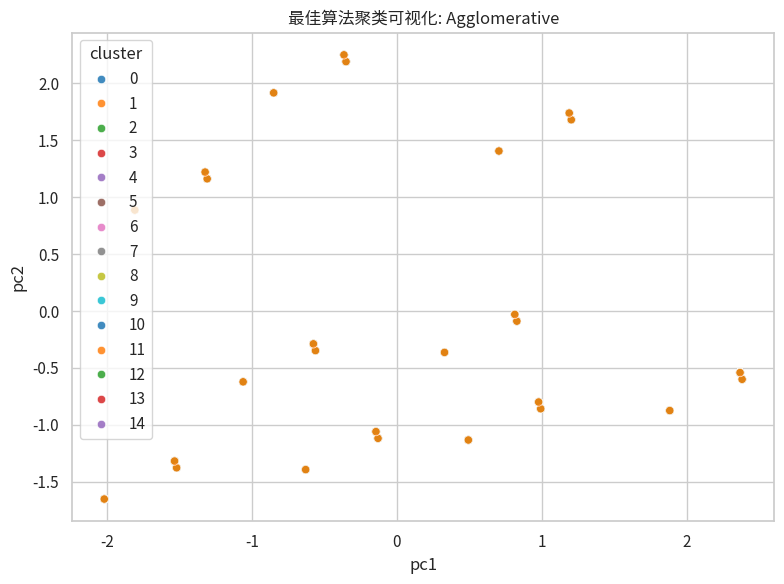

In [182]:
best_name = final_state["best_algorithm_name"]

result_key_map = {
    "KMeans": "kmeans_result",
    "DBSCAN": "dbscan_result",
    "Agglomerative": "agglomerative_result",
}

best_raw_result = final_state.get(result_key_map.get(best_name, ""), None)
best_labels = None if not best_raw_result else best_raw_result.get("best_labels")

plot_best_clusters(
    X_VISUAL,
    None if best_labels is None else np.asarray(best_labels),
    title=f"最佳算法聚类可视化: {best_name}",
)

 ## 23. 算法得分对比可视化

/mnt/data/tmp/lanshi/ipykernel_2316823/3245982426.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


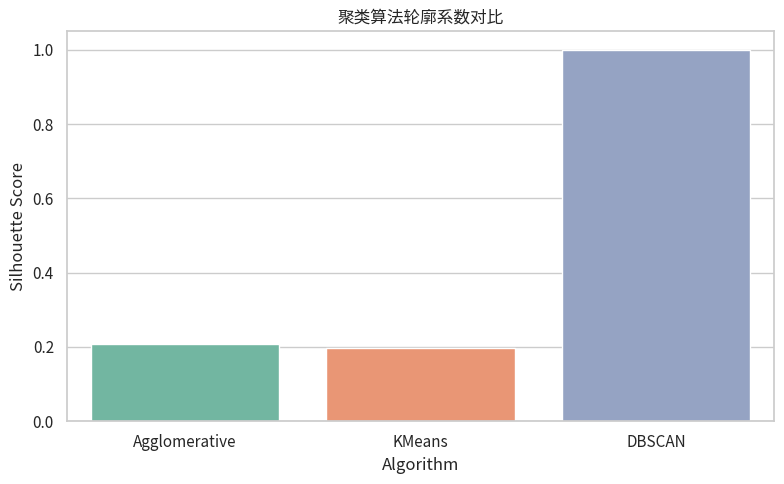

In [183]:
plot_comparison_table(comparison_df)

In [184]:
def show_history(result_dict: Optional[dict[str, Any]], title: str) -> pd.DataFrame:
    """Returns a DataFrame view of tuning history."""
    if not result_dict:
        return pd.DataFrame()
    history = result_dict.get("history", [])
    frame = pd.DataFrame(history)
    print(f"\n===== {title} =====")
    return frame


show_history(final_state.get("kmeans_result"), "KMeans History")


===== KMeans History =====


,round,space,best_score,best_params,best_labels,search_space
0,1,"{'min_clusters': 3, 'max_clusters': 15}",0.197806,{'n_clusters': 15},"[8, 1, 7, 8, 1, 7, 8, 1, 7, 8, 1, 7, 8, 1, 7, ...","{'min_clusters': 3, 'max_clusters': 15}"
1,2,"{'min_clusters': 2, 'max_clusters': 10}",0.165595,{'n_clusters': 4},"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","{'min_clusters': 2, 'max_clusters': 10}"
2,3,"{'min_clusters': 3, 'max_clusters': 10}",0.165595,{'n_clusters': 4},"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ...","{'min_clusters': 3, 'max_clusters': 10}"
3,4,"{'min_clusters': 2, 'max_clusters': 15}",0.197806,{'n_clusters': 15},"[8, 1, 7, 8, 1, 7, 8, 1, 7, 8, 1, 7, 8, 1, 7, ...","{'min_clusters': 2, 'max_clusters': 15}"
4,5,"{'min_clusters': 2, 'max_clusters': 15}",0.197806,{'n_clusters': 15},"[8, 1, 7, 8, 1, 7, 8, 1, 7, 8, 1, 7, 8, 1, 7, ...","{'min_clusters': 2, 'max_clusters': 15}"
5,6,"{'min_clusters': 4, 'max_clusters': 15}",0.197806,{'n_clusters': 15},"[8, 1, 7, 8, 1, 7, 8, 1, 7, 8, 1, 7, 8, 1, 7, ...","{'min_clusters': 4, 'max_clusters': 15}"


In [185]:
show_history(final_state.get("dbscan_result"), "DBSCAN History")


===== DBSCAN History =====


,round,space,best_score,best_params,best_labels,search_space
0,1,"{'eps_min': 0.1, 'eps_max': 1.5, 'eps_step': 0...",1.0,"{'eps': 0.1, 'min_samples': 2}","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","{'eps_min': 0.1, 'eps_max': 1.5, 'eps_step': 0..."


In [186]:
show_history(final_state.get("agglomerative_result"), "Agglomerative History")


===== Agglomerative History =====


,round,space,best_score,best_params,best_labels,search_space
0,1,"{'linkages': ['ward', 'complete', 'average', '...",0.165595,"{'linkage': 'ward', 'n_clusters': 4}","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'linkages': ('ward', 'complete', 'average', '..."
1,2,"{'linkages': ['ward', 'complete', 'average', '...",0.207495,"{'linkage': 'complete', 'n_clusters': 15}","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'linkages': ('ward', 'complete', 'average', '..."
2,3,"{'linkages': ['ward', 'complete', 'average', '...",0.207495,"{'linkage': 'complete', 'n_clusters': 15}","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'linkages': ('ward', 'complete', 'average', '..."
3,4,"{'linkages': ['complete'], 'min_clusters': 2, ...",0.207495,"{'linkage': 'complete', 'n_clusters': 15}","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'linkages': ('complete',), 'min_clusters': 2,..."
4,5,"{'linkages': ['ward', 'complete', 'average', '...",0.207495,"{'linkage': 'complete', 'n_clusters': 15}","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'linkages': ('ward', 'complete', 'average', '..."
5,6,"{'linkages': ['ward', 'complete', 'average', '...",0.207495,"{'linkage': 'complete', 'n_clusters': 15}","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{'linkages': ('ward', 'complete', 'average', '..."
